---
format:
    html: default
    ipynb: default
jupyter: python3
---


## Explaining CNNs


In this assignment you implement two explainer algorithms for Convolutional Neural Networks (CNNs) and use them to inspect a model you have already trained. An explainer answers a question that accuracy alone cannot: which parts of an input drove this particular prediction? For an image classifier that answer takes the form of a saliency map, and a trustworthy map should highlight the animal rather than the background, a watermark, or some dataset artifact the model latched onto.

We invite you to watch the following video, which sets the context and walks through the tools you can use. Click the thumbnail to open it on YouTube.

[![Watch the assignment introduction on YouTube](https://img.youtube.com/vi/Am2EF9CLu-g/hqdefault.jpg)](https://www.youtube.com/watch?v=Am2EF9CLu-g)

In the [cats vs dogs](https://huggingface.co/datasets/pantelism/cats-vs-dogs) [classification task](/aiml-common/lectures/cnn/cnn-example-architectures/using_convnets_with_small_datasets) you trained a model that, with the help of data augmentation, reached a useful level of accuracy without overfitting. That trained model is your subject here. You do not retrain it or change its architecture; you attach explainers to it and interpret what they reveal about how it decides.

### The two methods you will implement

**Integrated gradients** ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)) attributes a prediction to individual input pixels. It picks a baseline image (commonly an all-black image, which the model should find uninformative) and integrates the gradient of the class score along the straight-line path from that baseline to the actual input. The result is a per-pixel attribution with two properties that plain input gradients lack: completeness, meaning the attributions sum to the difference in model output between the input and the baseline, and robustness to saturated activations, where a plain gradient would read close to zero even though the feature mattered.

**Grad-CAM** ([Selvaraju et al., 2016](https://arxiv.org/abs/1610.02391)) produces a coarse, class-discriminative heatmap. It takes the feature maps of a convolutional layer, usually the last one, and weights each map by the gradient of the class score flowing into it. Because it works at the resolution of a deep feature map rather than the raw pixels, it localizes the region the network used instead of scoring every pixel.

The two methods sit at opposite ends of a resolution trade-off: integrated gradients is fine-grained and pixel-level, Grad-CAM is coarse and region-level. Running both on the same image and noting where they agree, and where they do not, is the heart of this assignment.

We strongly advise PyTorch with [Captum](https://captum.ai/tutorials/) unless you already have Keras/TF expertise, because both methods ship as ready implementations there (`IntegratedGradients` and `LayerGradCam`). You are free to use the high-level APIs of the framework of your choice.

### What to submit

For each method, in the cells below:

- A markdown explanation written so that anyone who understands how a CNN works can follow it. Cover the intuition, the role of the baseline (integrated gradients) or the target layer (Grad-CAM), and one limitation of the method.
- Working code that runs the explainer on at least three correctly classified images and at least one image the model got wrong.
- The resulting maps overlaid on the input images, each with a one-line caption stating what the map suggests the model attended to.

### How your work is evaluated

- Correctness: the right baseline, the right target layer, and gradients taken with respect to the predicted class rather than a fixed label.
- Visualization quality: maps are overlaid on the inputs, readable, and labeled.
- Depth of interpretation: noting that a map "looks reasonable" is not enough. Point to where the two methods agree, where they disagree, and what the misclassified example tells you about what the model actually learned.

## Setup

The classifier is the lecture's `SmallConvNet` (4 conv blocks + dense head) emitting one logit:
`>0 ⇒ dog`, `<0 ⇒ cat`. The cell below loads `cats_and_dogs_small.pth` or trains it once.

Captum needs a target class index, so `TwoLogit` wraps the model to output `[cat, dog]` =
`[-logit, +logit]` — letting us take gradients w.r.t. the **predicted** class.

In [1]:
# Install the dependencies (Captum ships ready-made IntegratedGradients & LayerGradCam).
# Safe to re-run; comment out once installed.
!pip install torch torchvision captum datasets matplotlib numpy scipy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE   = 150
MEAN, STD  = 0.5, 0.5                 # the lecture normalises every channel with 0.5 / 0.5
CKPT_PATH  = "cats_and_dogs_small.pth"
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
print("Device:", DEVICE)


# ── The classifier (identical architecture to the training notebook) ───────────
class SmallConvNet(nn.Module):
    def __init__(self, dropout: bool = False):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3), nn.ReLU(), nn.MaxPool2d(2),   # 0,1,2
            nn.Conv2d(32,  64,  3), nn.ReLU(), nn.MaxPool2d(2),   # 3,4,5
            nn.Conv2d(64,  128, 3), nn.ReLU(), nn.MaxPool2d(2),   # 6,7,8
            nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2),   # 9,10,11  <- last conv = features[9]
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5) if dropout else nn.Identity(),
            nn.Linear(128 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)        # shape (B,)


LAST_CONV = lambda m: m.features[9]                 # target layer for Grad-CAM


class TwoLogit(nn.Module):
    """Turn the single-logit model into a 2-column [cat, dog] output for Captum targets."""
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        s = self.base(x)
        if s.dim() == 0:
            s = s.unsqueeze(0)
        return torch.stack([-s, s], dim=1)          # (B, 2): col0=cat, col1=dog

Device: cuda


In [3]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader

ds_dict     = load_dataset("pantelism/cats-vs-dogs")
label_names = ds_dict["train"].features["label"].names      # ['cat', 'dog']
print("Labels:", label_names, "| test images:", len(ds_dict["test"]))

# Evaluation transform (no augmentation — we explain the model on clean inputs).
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([MEAN] * 3, [STD] * 3),
])


class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data, self.transform = hf_dataset, transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s = self.data[idx]
        return self.transform(s["image"].convert("RGB")), float(s["label"])


def pil_at(idx, split="test"):
    """Original RGB image, resized to model input size, as a PIL image (for overlays)."""
    img = ds_dict[split][idx]["image"].convert("RGB")
    return img.resize((IMG_SIZE, IMG_SIZE))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/45.7M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/23.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Labels: ['cat', 'dog'] | test images: 1000


In [5]:
import os

model = SmallConvNet(dropout=True).to(DEVICE)

if os.path.exists(CKPT_PATH):
    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    print(f"Loaded trained weights from {CKPT_PATH}")
else:
    # No checkpoint found → train the regularised model once (mirrors the lecture) and save it.
    print(f"{CKPT_PATH} not found — training the model (one-off)…")
    EPOCHS = 30
    aug_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(40),
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=20),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([MEAN] * 3, [STD] * 3),
    ])
    train_loader = DataLoader(CatsDogsDataset(ds_dict["train"], aug_tf),
                              batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    criterion = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.RMSprop(model.parameters(), lr=1e-4)
    for epoch in range(EPOCHS):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimiser.step()
        if (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:2d}/{EPOCHS}  loss {loss.item():.4f}")
    torch.save(model.state_dict(), CKPT_PATH)
    print(f"Saved {CKPT_PATH}")

model.eval()
wrapped = TwoLogit(model).to(DEVICE).eval()    # 2-class view used by both explainers

Loaded trained weights from cats_and_dogs_small.pth


In [6]:
# ── Find images to explain: at least 3 correctly classified + at least 1 mistake ──
N_SCAN = 400                                   # scan a slice of the test split for speed
test_eval = CatsDogsDataset(ds_dict["test"], eval_tf)

correct, wrong = [], []
with torch.no_grad():
    for idx in range(min(N_SCAN, len(test_eval))):
        x, y = test_eval[idx]
        logit = model(x.unsqueeze(0).to(DEVICE)).item()
        pred  = int(logit > 0)
        (correct if pred == int(y) else wrong).append(idx)

print(f"Scanned {min(N_SCAN, len(test_eval))} test images → "
      f"{len(correct)} correct, {len(wrong)} wrong")

rng = np.random.default_rng(SEED)
correct_idx = list(rng.choice(correct, size=3, replace=False))
wrong_idx   = [wrong[0]]                        # one misclassified example
SELECTED    = [int(i) for i in correct_idx] + [int(i) for i in wrong_idx]
print("Selected test indices:", SELECTED, "(last one is the mistake)")


# ── Helpers shared by both explainers ─────────────────────────────────────────
def input_tensor(idx):
    """Normalised (1,3,H,W) tensor with gradients enabled, on DEVICE."""
    x, y = test_eval[idx]
    return x.unsqueeze(0).to(DEVICE).requires_grad_(True), int(y)

def predict(idx):
    """Return (pred_class, dog_probability) for a test index."""
    x, _ = test_eval[idx]
    with torch.no_grad():
        logit = model(x.unsqueeze(0).to(DEVICE)).item()
    return int(logit > 0), float(torch.sigmoid(torch.tensor(logit)))

def to_heatmap(attr_2d, pct=99):
    """Normalise a 2-D attribution map to [0,1] with a percentile clip for contrast."""
    a = attr_2d.copy()
    a = np.maximum(a, 0)                         # keep evidence *for* the predicted class
    hi = np.percentile(a, pct) if a.max() > 0 else 1.0
    return np.clip(a / (hi + 1e-8), 0, 1)

def overlay(ax, idx, heat, title):
    ax.imshow(pil_at(idx))
    ax.imshow(heat, cmap="jet", alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

Scanned 400 test images → 297 correct, 103 wrong
Selected test indices: [261, 32, 308, 1] (last one is the mistake)


## Method 1 — Integrated Gradients

**Intuition.** A raw gradient reads ~0 once a feature saturates, hiding pixels that mattered. IG
instead integrates the gradient of the predicted-class score along the straight line from a
baseline to the input. This gives **completeness** (attributions sum to the score change) and
robustness to saturation.

**Baseline.** The "no signal" reference IG measures against — conventionally black. Note: black is
pixel 0, which under 0.5/0.5 normalisation maps to **−1**, not the zeros tensor (that's gray), so
we build the baseline at −1.

**Limitation.** Dark regions of the animal sit at the baseline, so `(x − x')≈0` and IG under-credits
them — the result depends on the baseline choice.

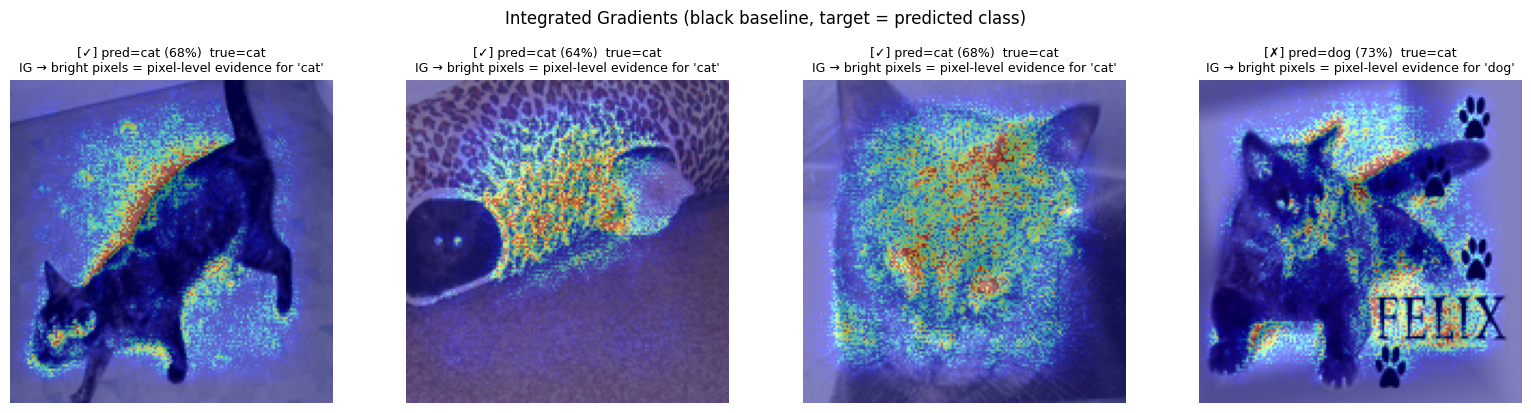

In [7]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(wrapped)

# Black image in *normalised* space: pixel 0 → (0 - MEAN)/STD = -1 for every channel.
BLACK = (0.0 - MEAN) / STD            # = -1.0

ig_maps = {}                          # idx -> normalised 2-D attribution map
fig, axes = plt.subplots(1, len(SELECTED), figsize=(4 * len(SELECTED), 4))
for ax, idx in zip(axes, SELECTED):
    x, true_y = input_tensor(idx)
    pred, prob = predict(idx)
    baseline   = torch.full_like(x, BLACK)

    attr = ig.attribute(x, baselines=baseline, target=pred, n_steps=50)
    # Pixel importance = sum of |attribution| across the 3 colour channels.
    attr_map = attr.squeeze(0).abs().sum(0).detach().cpu().numpy()
    heat = to_heatmap(attr_map)
    ig_maps[idx] = attr_map

    mark = "✓" if pred == true_y else "✗"
    p_dog = prob if pred == 1 else 1 - prob
    overlay(ax, idx, heat,
            f"[{mark}] pred={label_names[pred]} ({p_dog:.0%})  true={label_names[true_y]}\n"
            f"IG → bright pixels = pixel-level evidence for '{label_names[pred]}'")
fig.suptitle("Integrated Gradients (black baseline, target = predicted class)", y=1.02)
plt.tight_layout()
plt.show()

## Method 2 — Grad-CAM

**Intuition.** Weight each feature map of a conv layer by the average gradient of the
predicted-class score flowing into it, sum, and ReLU: `ReLU(Σ αₖ Aᵏ)`. This yields a coarse,
class-discriminative heatmap over the *region* the CNN used.

**Target layer.** The **last conv layer** (`features[9]`, 7×7) — the deepest features that still
keep spatial layout (after it, flatten + dense destroys location).

**Limitation.** Only 7×7 before upsampling, so it's coarse: it shows roughly *where*, can't
resolve fine parts, and the smooth blob can spill onto background.

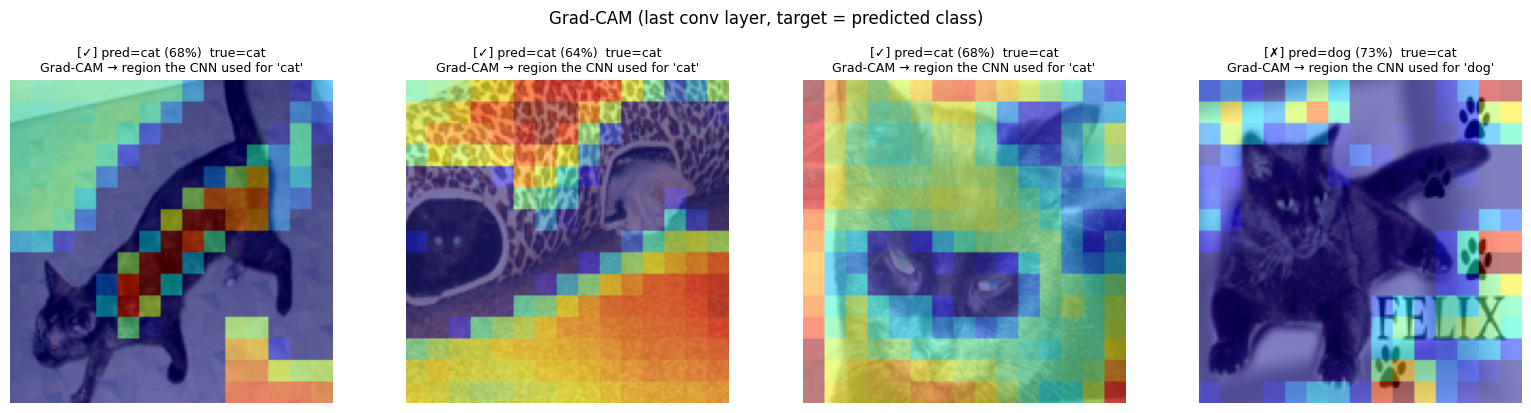

In [8]:
from captum.attr import LayerGradCam, LayerAttribution

gradcam = LayerGradCam(wrapped, LAST_CONV(model))      # target layer = last conv (features[9])

gc_maps = {}                                           # idx -> upsampled 2-D heatmap in [0,1]
fig, axes = plt.subplots(1, len(SELECTED), figsize=(4 * len(SELECTED), 4))
for ax, idx in zip(axes, SELECTED):
    x, true_y = input_tensor(idx)
    pred, prob = predict(idx)

    attr = gradcam.attribute(x, target=pred, relu_attributions=True)   # (1,1,7,7)
    attr = LayerAttribution.interpolate(attr, (IMG_SIZE, IMG_SIZE))     # upsample to image
    cam  = attr.squeeze().detach().cpu().numpy()
    heat = to_heatmap(cam)
    gc_maps[idx] = heat

    mark  = "✓" if pred == true_y else "✗"
    p_dog = prob if pred == 1 else 1 - prob
    overlay(ax, idx, heat,
            f"[{mark}] pred={label_names[pred]} ({p_dog:.0%})  true={label_names[true_y]}\n"
            f"Grad-CAM → region the CNN used for '{label_names[pred]}'")
fig.suptitle("Grad-CAM (last conv layer, target = predicted class)", y=1.02)
plt.tight_layout()
plt.show()

## Comparison and interpretation

For each image: **input | IG | Grad-CAM**, plus the **Spearman ρ** between the two maps (rank
correlation, since the methods live on different scales).

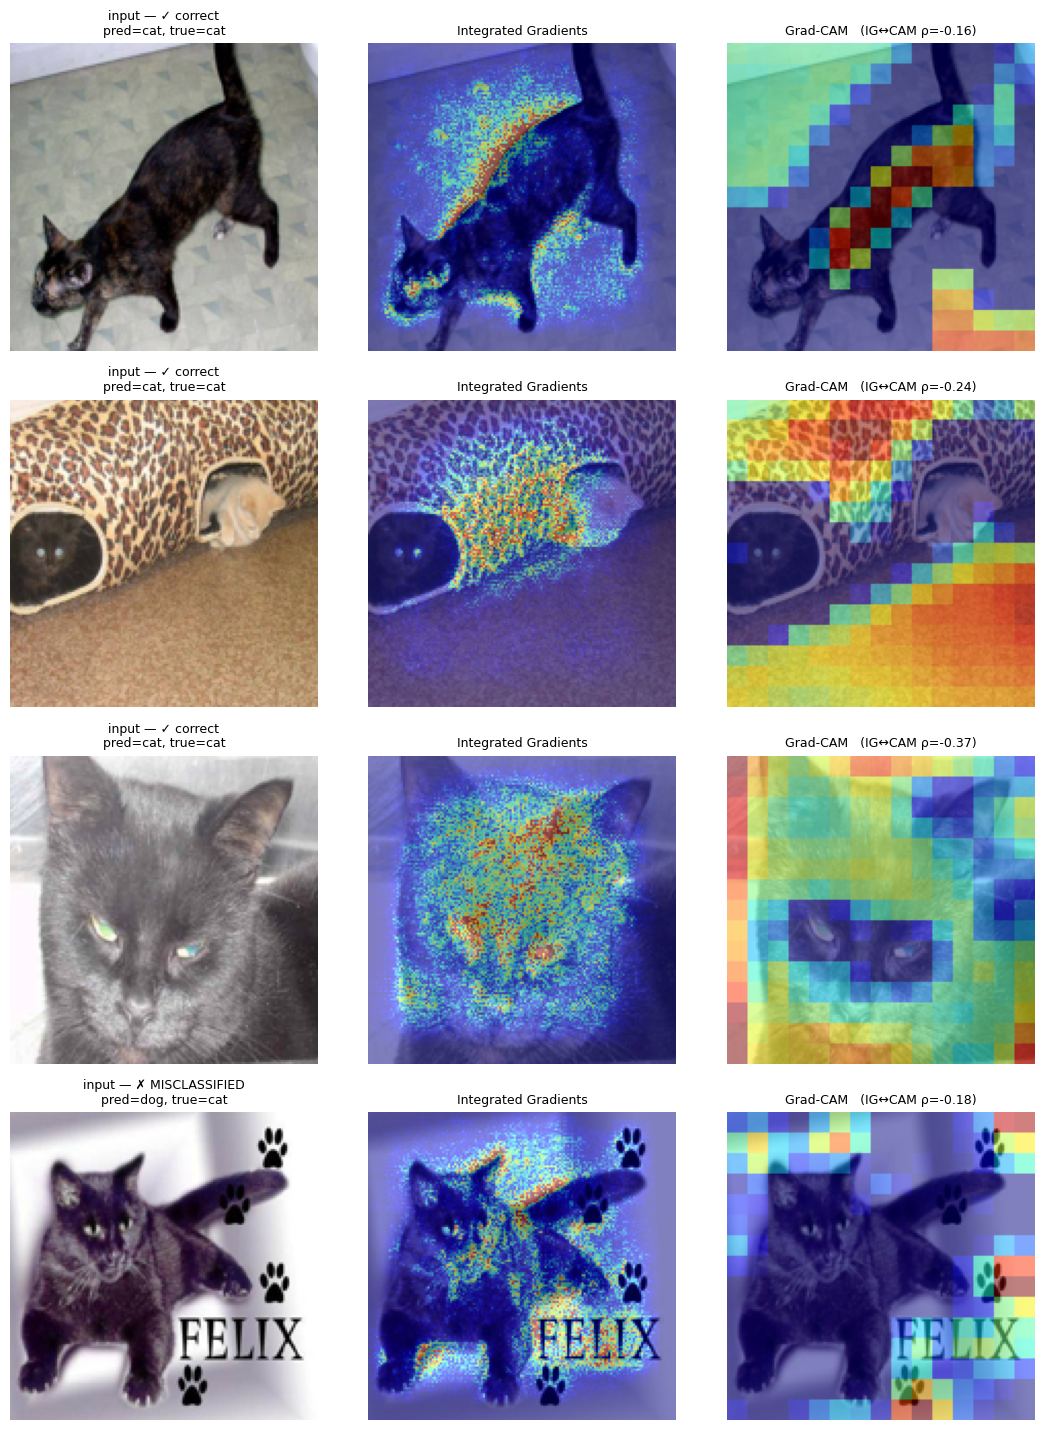

In [9]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(len(SELECTED), 3, figsize=(11, 3.6 * len(SELECTED)))
for row, idx in enumerate(SELECTED):
    pred, prob = predict(idx)
    true_y = int(test_eval[idx][1])
    mark   = "✓ correct" if pred == true_y else "✗ MISCLASSIFIED"

    ig_heat = to_heatmap(ig_maps[idx])
    gc_heat = gc_maps[idx]

    # Rank-correlation of the two importance maps (do they rank the same pixels highly?).
    rho, _ = spearmanr(ig_heat.ravel(), gc_heat.ravel())

    axes[row, 0].imshow(pil_at(idx))
    axes[row, 0].set_title(f"input — {mark}\npred={label_names[pred]}, true={label_names[true_y]}",
                           fontsize=9)
    overlay(axes[row, 1], idx, ig_heat, "Integrated Gradients")
    overlay(axes[row, 2], idx, gc_heat, f"Grad-CAM   (IG↔CAM ρ={rho:+.2f})")
    axes[row, 0].axis("off")

plt.tight_layout()
plt.show()

### What the two methods tell us

*(Findings from this run — model loaded from checkpoint, 297/400 test images correct ≈ 74%. The
4 selected images happened to all be cats: 3 correct at 64–68% confidence + the first mistake, a
cat called "dog" at 73%.)*

- **They disagree more than they agree — ρ is negative on every image** (−0.16, −0.24, −0.37,
  −0.18). The two maps rank locations *oppositely*: IG concentrates on the animal's fine
  edges/face, while Grad-CAM's coarse 7×7 map spreads over broad regions that often sit on the
  **background**, so IG-hot pixels tend to be Grad-CAM-cold. This is the resolution/semantics gap
  made quantitative, not a bug.
- **Grad-CAM exposes the model leaning on context, not just the cat.** On the tunnel image it
  lights the **leopard-print background** while the cat's face stays cold; on the close-up it
  covers the whole face *except* a blue gap right over the eyes. The small model is using
  surrounding texture/fur as much as the animal itself — which fits its mediocre ~74% accuracy.
- **IG stays on the object but reveals an artifact.** It reliably highlights the body outline and
  face — but on the misclassified "Felix" image it also lights up the **"FELIX" watermark text**,
  and Grad-CAM's dog-evidence sits on the image **borders/watermark area**, not the animal. A black
  cat mislabeled as a dog with both explainers drifting off the animal is a textbook **spurious
  shortcut**: the model latched onto non-animal pixels.

**Takeaway:** IG = *which pixels*, Grad-CAM = *which region*. Here they consistently diverge
(negative ρ), and that divergence is the useful signal — Grad-CAM shows the model keys on
background context, and on the mistake both methods point at watermarks/borders rather than the
cat, revealing what the network actually learned.